# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv(r'C:\Users\mazur\data_analysis\data\yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [5]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Post-monsoon', 11: 'Post-monsoon'
}

df['season_text'] = df['month'].map(season_map)

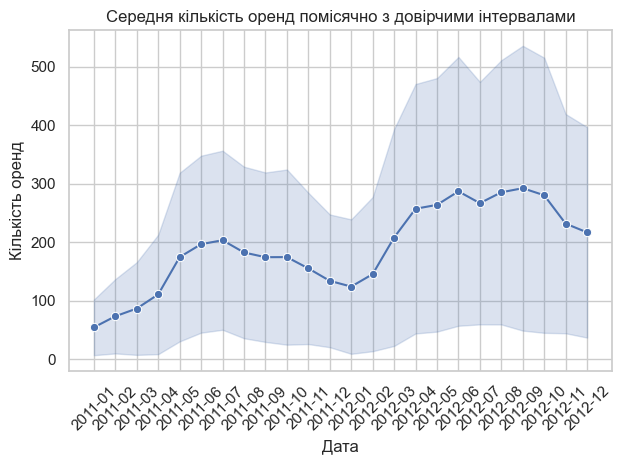

In [16]:
avg_month_count = df.groupby('month_year')['count'].mean()

sns.lineplot(
    data=df,
    x = 'month_year',
    y= 'count',
    errorbar='sd',
    marker='o')
plt.title('Середня кількість оренд помісячно з довірчими інтервалами')
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout();


In [ ]:
- В які місяці найбільша невизначеність в даних?
З березня по вересень найбільший розкид даних.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

In [17]:
df['temp']

datetime
2011-01-01 00:00:00     9.84
2011-01-01 01:00:00     9.02
2011-01-01 02:00:00     9.02
2011-01-01 03:00:00     9.84
2011-01-01 04:00:00     9.84
                       ...  
2012-12-19 19:00:00    15.58
2012-12-19 20:00:00    14.76
2012-12-19 21:00:00    13.94
2012-12-19 22:00:00    13.94
2012-12-19 23:00:00    13.12
Name: temp, Length: 10886, dtype: float64

Text(0, 0.5, 'Частота')

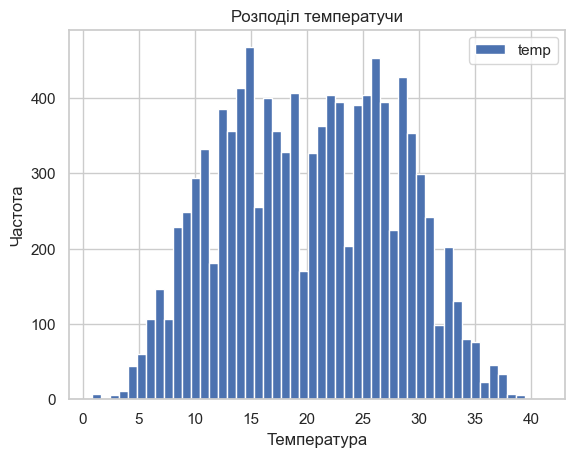

In [34]:
df.plot.hist(column='temp', bins=50);

plt.title('Розподіл температучи')
plt.xlabel('Температура')
plt.ylabel('Частота')

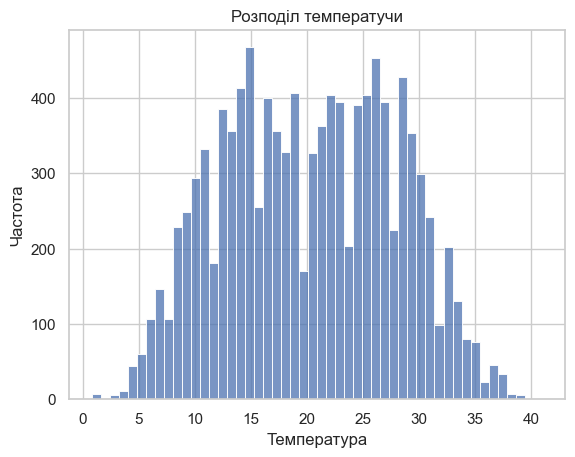

In [ ]:
sns.histplot(data=df['temp'], bins=50, kde=True);

plt.title('Розподіл температучи')
plt.xlabel('Температура')
plt.ylabel('Частота');

In [ ]:
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
Seaborn додає прозорість, а plt легенду.

2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?
Показую криву розподілу, наскільки щільно розташовані дані

SyntaxError: invalid syntax (1316561485.py, line 2)

Text(0, 0.5, 'Частота')

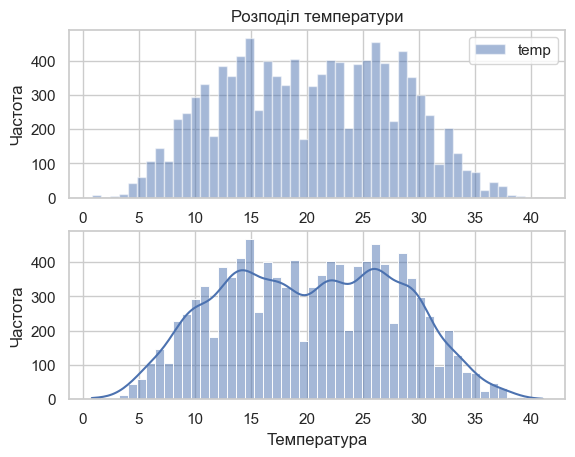

In [59]:
fig, ax = plt.subplots(2,1)

df.plot.hist(column='temp', bins=50, alpha=0.5, ax=ax[0]); 
ax[0].set_title('Розподіл температури')
ax[0].set_ylabel('Частота')

sns.histplot(data=df['temp'], bins=50, kde=True, alpha=0.5, ax=ax[1]);
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Частота')

Text(44.25, 0.5, 'Температура')

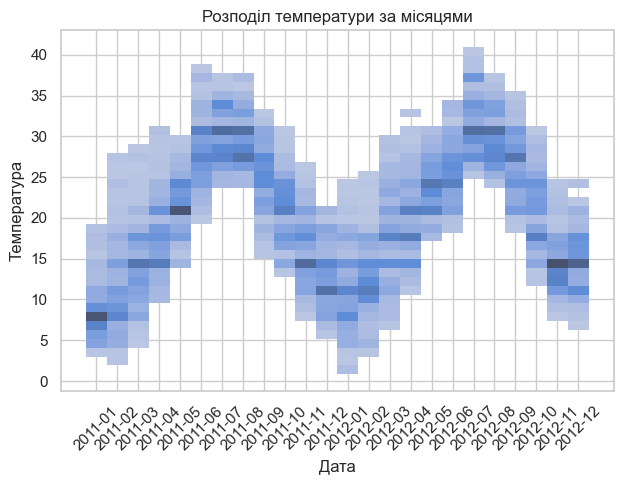

In [36]:
sns.histplot(data= df, x='month_year', y='temp', kde=True)
plt.xticks(rotation=45)
plt.tight_layout();
plt.title('Розподіл температури за місяцями')
plt.xlabel('Дата')
plt.ylabel('Температура')

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [63]:
df['count']

datetime
2011-01-01 00:00:00     16
2011-01-01 01:00:00     40
2011-01-01 02:00:00     32
2011-01-01 03:00:00     13
2011-01-01 04:00:00      1
                      ... 
2012-12-19 19:00:00    336
2012-12-19 20:00:00    241
2012-12-19 21:00:00    168
2012-12-19 22:00:00    129
2012-12-19 23:00:00     88
Name: count, Length: 10886, dtype: int64

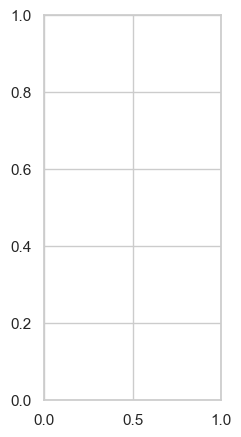

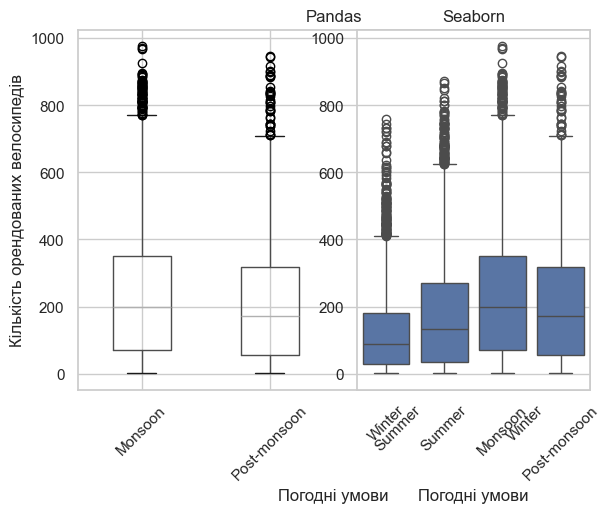

In [ ]:
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)

df.boxplot(column='count', by='season_text')
plt.title('Pandas')
plt.suptitle('') 
plt.xlabel('Погодні умови')
plt.ylabel('Кількість орендованих велосипедів')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)

sns.boxplot(data=df, x='season_text', y='count')
plt.title('Seaborn')
plt.xlabel('Погодні умови')
plt.ylabel('')
plt.xticks(rotation=45)




In [ ]:
Яка візуальна різниця між Pandas та Seaborn бокс-плотами?
seabon додає забарвлення боксам по замовчуванню, pandas ні.
pandas відразу сортує вісь х по спаданню.

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

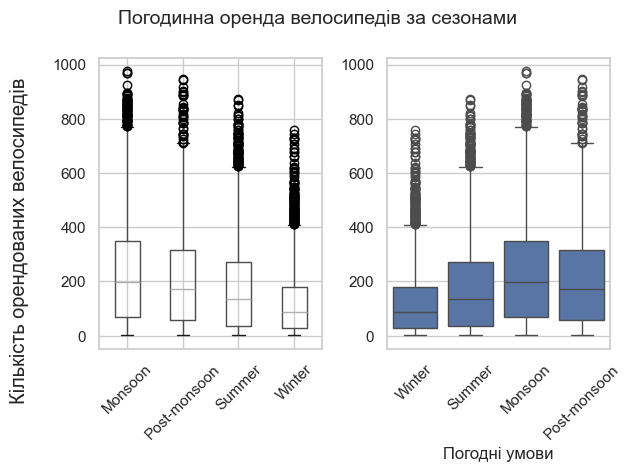

In [124]:
fig, ax = plt.subplots(1,2)

df.boxplot(column='count', by='season_text', ax=ax[0]); 
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title('')
ax[0].set_xlabel('')
plt.tight_layout()

sns.boxplot(data=df, x='season_text', y='count', ax=ax[1]
            #,order=['Monsoon', 'Post-Monsoon', 'Summer', 'Winter']
            )
ax[1].set_xlabel('Погодні умови')
ax[1].set_ylabel('')
plt.xticks(rotation=45)
plt.tight_layout();

fig.suptitle('Погодинна оренда велосипедів за сезонами', fontsize=14)
fig.supylabel('Кількість орендованих велосипедів')

plt.tight_layout()
plt.subplots_adjust(top=0.88)

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


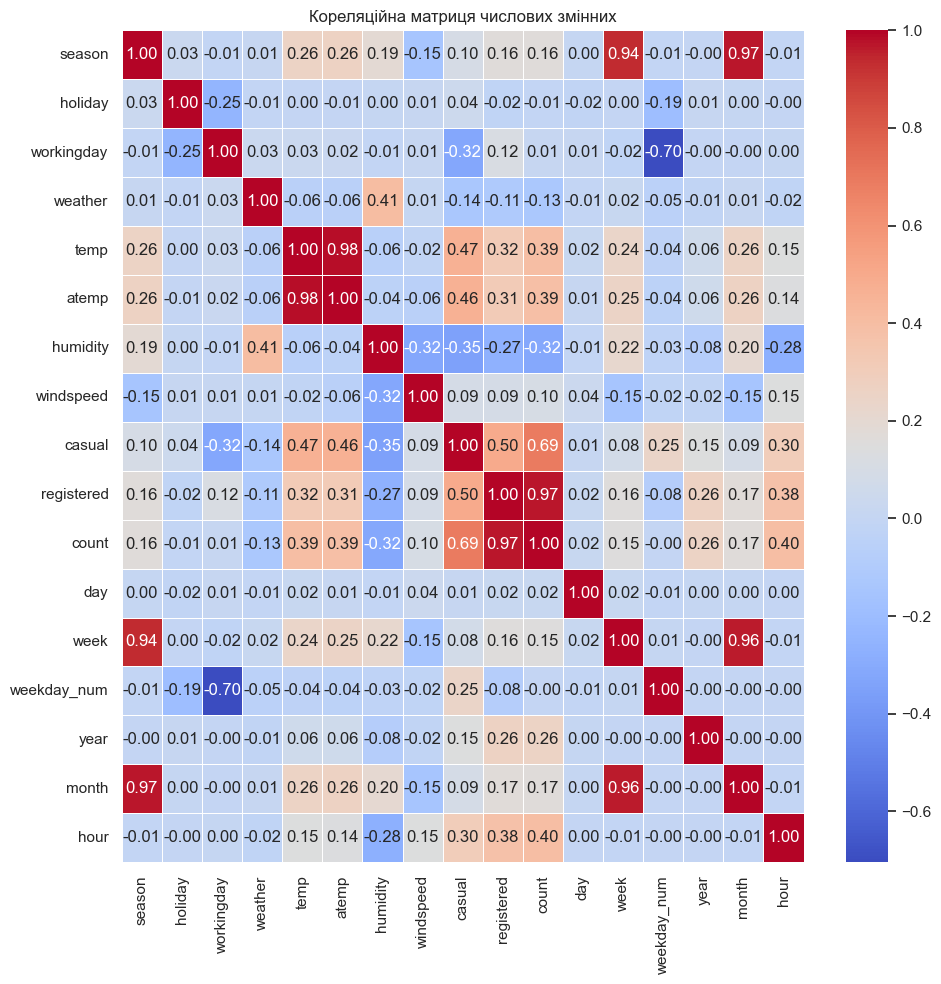

In [148]:
correlation = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,10))

sns.heatmap(correlation,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    linewidths=0.5    
    )

plt.title("Кореляційна матриця числових змінних")
plt.tight_layout()

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


<Axes: xlabel='season_text', ylabel='count'>

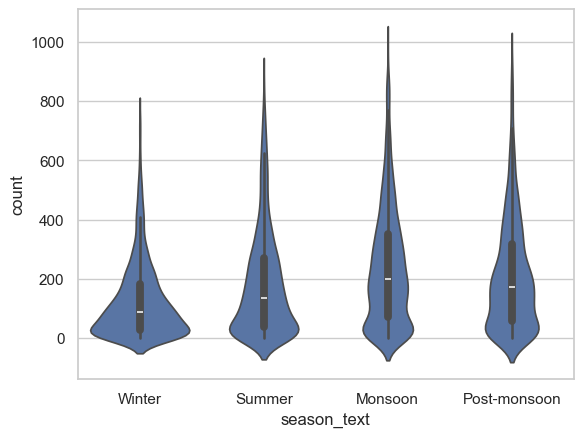

In [139]:
sns.violinplot(data=df, x='season_text', y='count')

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?